In [1]:
import sys
import os
import warnings
from datetime import datetime, timezone, timedelta
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
import json
from zoneinfo import ZoneInfo
from pandas import Timestamp
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from scipy.stats import norm

current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.insert(0, str(parent_dir))
from lib import *

MODEL_PATH=parent_dir / 'models' 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

In [2]:
example_ticker = "KXBTC15M-26MAY040515-15"
lookback_minutes = 8000
series, event_dt = parse_kalshi_15m_event_ticker(example_ticker)
dt_only = get_ticker_datetime(example_ticker)
# crypto_at = datetime(2026,5,5,0,0,tzinfo=ZoneInfo('America/Chicago'))
crypto_at = datetime.now(tz=ZoneInfo('America/Chicago'))
df_api = get_market_data_from_api(series, crypto_at, lookback_minutes)
df_api = df_api.set_index('datetime')
df_api.head()

API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY070215-15/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY070215-15&start_ts=1778133300&end_ts=1778134500&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY070230-30/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY070230-30&start_ts=1778134200&end_ts=1778135400&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting ma

,ticker,floor_strike,yes_ask_low_dollar,yes_bid_high_dollar,no_ask_low_dollar,no_bid_high_dollar
datetime,,,,,,
2026-05-06 06:46:00-05:00,KXBTC15M-26MAY060800-00,82494.83,0.41,0.61,1.00,0.001
2026-05-06 06:47:00-05:00,KXBTC15M-26MAY060800-00,82494.83,0.44,0.60,0.57,0.390
2026-05-06 06:48:00-05:00,KXBTC15M-26MAY060800-00,82494.83,0.49,0.71,0.52,0.280
2026-05-06 06:49:00-05:00,KXBTC15M-26MAY060800-00,82494.83,0.48,0.68,0.53,0.310
2026-05-06 06:50:00-05:00,KXBTC15M-26MAY060800-00,82494.83,0.52,0.68,0.49,0.310


In [3]:
df_crypto = get_crypto_past_minutes(series, crypto_at, lookback_minutes)
df_crypto['datetime'] = pd.to_datetime(df_crypto['datetime'])
df_crypto['datetime'] = df_crypto['datetime'].dt.tz_convert('America/Chicago')
df_crypto['datetime'] = df_crypto['datetime'].dt.floor('min')
df_crypto = df_crypto.set_index('datetime')
filter_timestamp = df_crypto[df_crypto.index.minute.isin([0,15,30,45])].index[0]
df_crypto = df_crypto[df_crypto.index >= filter_timestamp]
df_crypto.head()

,open,high,low,close,tick_count
datetime,,,,,
2026-05-03 20:30:00-05:00,78544.30,78544.30,78544.30,78544.30,0
2026-05-03 20:31:00-05:00,78583.26,78583.26,78583.26,78583.26,0
2026-05-03 20:32:00-05:00,78697.17,78697.17,78697.17,78697.17,0
2026-05-03 20:33:00-05:00,78925.09,79005.36,78892.57,79000.85,41
2026-05-03 20:34:00-05:00,78990.53,78990.53,78936.38,78936.38,0


In [4]:
df_merged = df_crypto.join(df_api, how='left')
df_merged = df_merged.dropna()
df_merged.head()

,open,high,low,close,tick_count,ticker,floor_strike,yes_ask_low_dollar,yes_bid_high_dollar,no_ask_low_dollar,no_bid_high_dollar
datetime,,,,,,,,,,,
2026-05-06 06:46:00-05:00,82490.40,82494.28,82469.75,82469.75,30,KXBTC15M-26MAY060800-00,82494.83,0.41,0.61,1.00,0.001
2026-05-06 06:47:00-05:00,82469.75,82469.75,82469.75,82469.75,0,KXBTC15M-26MAY060800-00,82494.83,0.44,0.60,0.57,0.390
2026-05-06 06:48:00-05:00,82486.12,82486.12,82486.12,82486.12,0,KXBTC15M-26MAY060800-00,82494.83,0.49,0.71,0.52,0.280
2026-05-06 06:49:00-05:00,82529.69,82529.69,82529.69,82529.69,0,KXBTC15M-26MAY060800-00,82494.83,0.48,0.68,0.53,0.310
2026-05-06 06:50:00-05:00,82498.69,82540.23,82498.11,82515.81,57,KXBTC15M-26MAY060800-00,82494.83,0.52,0.68,0.49,0.310


In [145]:
df_calc = df_merged

In [146]:
df_calc['yes_dist'] = df_calc['close'] - df_calc['floor_strike']
df_calc['log_return'] = np.log(df_calc['close'] / df_calc['close'].shift(1))
df_calc['m3_log_return'] = df_calc['log_return'].rolling(3).std()
df_calc['m5_log_return'] = df_calc['log_return'].rolling(5).std()
df_calc['ma3'] = df_calc['close'].rolling(3).mean()
df_calc['ma5'] = df_calc['close'].rolling(5).mean()
df_calc['ma3_vs_strike'] = (df_calc['ma3'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc['ma5_vs_strike'] = (df_calc['ma5'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc['yes_dist_pct'] = df_calc['yes_dist'] / df_calc['floor_strike'] * 100
df_calc['m1_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(1)
df_calc['m3_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(3)
df_calc['m5_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(5)
df_calc['time_decay'] = np.where(df_calc.index.minute % 15 == 15, 0, 15 - df_calc.index.minute % 15)
df_calc['hour'] = df_calc.index.hour
df_calc['minute'] = df_calc.index.minute

In [147]:
df_calc = df_calc.dropna()

In [148]:
df_calc.head()

,open,high,low,close,tick_count,ticker,floor_strike,yes_ask_low_dollar,yes_bid_high_dollar,no_ask_low_dollar,no_bid_high_dollar,yes_dist,log_return,3m_log_return,5m_log_return,ma3,ma5,ma3_vs_strike,ma5_vs_strike,yes_dist_pct,1m_yes_dist_momentum,3m_yes_dist_momentum,5m_yes_dist_momentum,time_decay,m3_log_return,m5_log_return,m1_yes_dist_momentum,m3_yes_dist_momentum,m5_yes_dist_momentum,hour,minute
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-06 06:51:00-05:00,82519.10,82553.11,82518.00,82543.41,51,KXBTC15M-26MAY060800-00,82494.83,0.60,0.76,0.42,0.23,48.58,0.000334,0.000359,0.000273,82529.636667,82508.956,0.042193,0.017123,0.058889,27.60,57.29,73.66,9,0.000359,0.000273,27.60,57.29,73.66,6,51
2026-05-06 06:52:00-05:00,82561.30,82561.30,82544.19,82544.87,19,KXBTC15M-26MAY060800-00,82494.83,0.60,0.74,0.42,0.25,50.04,0.000018,0.000254,0.000271,82534.696667,82523.980,0.048326,0.035336,0.060658,1.46,15.18,75.12,8,0.000254,0.000271,1.46,15.18,75.12,6,52
2026-05-06 06:53:00-05:00,82545.46,82545.46,82519.33,82521.04,26,KXBTC15M-26MAY060800-00,82494.83,0.62,0.71,0.39,0.28,26.21,-0.000289,0.000312,0.000342,82536.440000,82530.964,0.050440,0.043802,0.031772,-23.83,5.23,34.92,7,0.000312,0.000342,-23.83,5.23,34.92,6,53
2026-05-06 06:54:00-05:00,82526.79,82538.35,82522.85,82528.14,16,KXBTC15M-26MAY060800-00,82494.83,0.62,0.72,0.39,0.27,33.31,0.000086,0.000200,0.000240,82531.350000,82530.654,0.044269,0.043426,0.040378,7.10,-15.27,-1.55,6,0.000200,0.000240,7.10,-15.27,-1.55,6,54
2026-05-06 06:55:00-05:00,82533.49,82533.49,82511.79,82522.66,34,KXBTC15M-26MAY060800-00,82494.83,0.61,0.74,0.40,0.25,27.83,-0.000066,0.000188,0.000227,82523.946667,82532.024,0.035295,0.045086,0.033735,-5.48,-22.21,6.85,5,0.000188,0.000227,-5.48,-22.21,6.85,6,55


In [149]:
def agg_data_function(df, column, *data_cents):
    results = {cent: [] for cent in data_cents}
    triggered = set() 
    
    for i in range(len(df)):
        row = df.iloc[i]
        
        if row['time_decay'] == 0:
            continue
        
        current_ticker = row['ticker']
        
        for cent in data_cents:
            if (current_ticker, cent) in triggered:
                continue
                
            if float(row[column + '_ask_low_dollar']) < float(cent):
                triggered.add((current_ticker, cent)) 
                
                high_price = 0
                low_price = 1
                
                for j in range(1, 16):
                    if i + j >= len(df):
                        break
                    next_row = df.iloc[i + j]
                    high_price = max(next_row[column + '_bid_high_dollar'], high_price)
                    low_price = min(next_row[column + '_bid_high_dollar'], low_price)
                    if next_row['ticker'] != current_ticker or next_row['time_decay'] == 15:
                        break
                
                tmp_dict = row.to_dict()
                tmp_dict['subsequent_high'] = high_price
                tmp_dict['subsequent_low'] = low_price
                tmp_dict['reached_30'] = 1 if high_price >= 0.30 else 0
                tmp_dict['reached_40'] = 1 if high_price >= 0.40 else 0
                tmp_dict['reached_50'] = 1 if high_price >= 0.50 else 0
                tmp_dict['reached_60'] = 1 if high_price >= 0.60 else 0
                tmp_dict['reached_70'] = 1 if high_price >= 0.7 else 0
                tmp_dict['reached_90'] = 1 if high_price >= 0.9 else 0
                results[cent].append(tmp_dict)
    
    return results

In [150]:
res=agg_data_function(df_calc, 'yes', *[0.1,0.15,0.2,0.25,0.3,0.35])

In [151]:
# win rate analysis
comb_10 = pd.DataFrame(res[0.10])
comb_15 = pd.DataFrame(res[0.15])
comb_20 = pd.DataFrame(res[0.2])
comb_25 = pd.DataFrame(res[0.25])
comb_30 = pd.DataFrame(res[0.3])
comb_35 = pd.DataFrame(res[0.35])

In [152]:
def get_protential_pnl(df, entry_price, *exit_price):
    for price in exit_price:
        col_name = f"reached_{int(price * 100)}"
        if col_name in df.columns:
            rate = (df[col_name] == 1).sum() / len(df)
            pnl = rate * (float(price) - float(entry_price))
            print(f"Entry: {entry_price}, Exit: {price}, win rate: {rate:.2%}, PNL: {pnl:.4f}")

In [153]:
def evaluate_feature(good_mean, good_std, bad_mean, bad_std):
    diff = good_mean - bad_mean
    avg_std = (good_std + bad_std) / 2
    
    if avg_std < 1e-10:
        return None
    
    ratio = abs(diff) / avg_std
    
    if ratio > 0.5:
        grade = 'strong'
    elif ratio > 0.3:
        grade = 'medium'
    elif ratio > 0.15:
        grade = 'weak'
    else:
        grade = 'useless'
    
    return ratio, grade

In [154]:
get_protential_pnl(comb_10,0.10,*[0.3,0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_15,0.15,*[0.3,0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_20,0.20,*[0.3,0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_25,0.25,*[0.3,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_30,0.30,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_35,0.35,*[0.5,0.6,0.7,0.9])

Entry: 0.1, Exit: 0.3, win rate: 30.38%, PNL: 0.0608
Entry: 0.1, Exit: 0.4, win rate: 26.58%, PNL: 0.0797
Entry: 0.1, Exit: 0.5, win rate: 23.42%, PNL: 0.0937
Entry: 0.1, Exit: 0.6, win rate: 19.62%, PNL: 0.0981
Entry: 0.1, Exit: 0.7, win rate: 12.66%, PNL: 0.0759
Entry: 0.1, Exit: 0.9, win rate: 7.59%, PNL: 0.0608
Entry: 0.15, Exit: 0.3, win rate: 38.82%, PNL: 0.0582
Entry: 0.15, Exit: 0.4, win rate: 33.53%, PNL: 0.0838
Entry: 0.15, Exit: 0.5, win rate: 28.82%, PNL: 0.1009
Entry: 0.15, Exit: 0.6, win rate: 24.71%, PNL: 0.1112
Entry: 0.15, Exit: 0.7, win rate: 20.00%, PNL: 0.1100
Entry: 0.15, Exit: 0.9, win rate: 14.71%, PNL: 0.1103
Entry: 0.2, Exit: 0.3, win rate: 49.72%, PNL: 0.0497
Entry: 0.2, Exit: 0.4, win rate: 39.66%, PNL: 0.0793
Entry: 0.2, Exit: 0.5, win rate: 33.52%, PNL: 0.1006
Entry: 0.2, Exit: 0.6, win rate: 28.49%, PNL: 0.1140
Entry: 0.2, Exit: 0.7, win rate: 24.58%, PNL: 0.1229
Entry: 0.2, Exit: 0.9, win rate: 18.44%, PNL: 0.1291
Entry: 0.25, Exit: 0.3, win rate: 62.63%,

In [155]:
feature_cols = [     
    'yes_dist',         
    'log_return',  
    'm3_log_return',
    'm5_log_return',  
    'ma3_vs_strike',
    'ma5_vs_strike',            
    'yes_dist_pct',
    'm1_yes_dist_momentum',
    'm3_yes_dist_momentum',
    'm5_yes_dist_momentum',
    'time_decay',
    'hour',
    'minute',
]

comb_list = [0.1, 0.15, 0.2, 0.25]
reached_list = ['reached_30','reached_40', 'reached_50', 'reached_60', 'reached_70', 'reached_90']

for comb in comb_list: 
    for reached in reached_list:
        df_results = pd.DataFrame(res[comb])
        df_expected = df_results[reached]
        
        # Separate good and bad outcomes
        good = df_results[df_expected == 1]
        bad = df_results[df_expected == 0]
        
        # Prior probabilities
        prior_good = len(good) / len(df_results)
        prior_bad = len(bad) / len(df_results)
        print(f"Comb is {comb}, reached is {reached}")
        print(f"Prior P(Good) = {prior_good:.4f}, P(Bad) = {prior_bad:.4f}")
        likelihoods = {}
        good_ratio_count = 0
        for col in feature_cols:
            good_mean, good_std = good[col].mean(), good[col].std()
            bad_mean, bad_std = bad[col].mean(), bad[col].std()
            
            likelihoods[col] = {
                'good': (good_mean, good_std),
                'bad': (bad_mean, bad_std),
            }
            
            diff = good_mean - bad_mean
            ratio, grade = evaluate_feature(good_mean, good_std, bad_mean, bad_std)
            if grade == 'strong':
                good_ratio_count += 1
            print(f"{grade} -> {col}: Good={good_mean:.4f}, Bad={bad_mean:.4f}, Diff={diff:.4f}")
        print(f"Total Good Ratio is {good_ratio_count}\n")

Comb is 0.1, reached is reached_30
Prior P(Good) = 0.3038, P(Bad) = 0.6962
strong -> yes_dist: Good=-23.5973, Bad=-63.1335, Diff=39.5362
medium -> log_return: Good=-0.0001, Bad=-0.0003, Diff=0.0002
medium -> m3_log_return: Good=0.0002, Bad=0.0004, Diff=-0.0001
medium -> m5_log_return: Good=0.0003, Bad=0.0004, Diff=-0.0001
strong -> ma3_vs_strike: Good=-0.0189, Bad=-0.0529, Diff=0.0339
strong -> ma5_vs_strike: Good=-0.0108, Bad=-0.0393, Diff=0.0284
strong -> yes_dist_pct: Good=-0.0292, Bad=-0.0779, Diff=0.0487
medium -> m1_yes_dist_momentum: Good=-8.6708, Bad=-22.3524, Diff=13.6815
medium -> m3_yes_dist_momentum: Good=-14.0158, Bad=-40.0806, Diff=26.0648
medium -> m5_yes_dist_momentum: Good=-26.8194, Bad=-56.0726, Diff=29.2533
strong -> time_decay: Good=7.6458, Bad=5.5182, Diff=2.1277
medium -> hour: Good=10.4792, Bad=8.9182, Diff=1.5610
weak -> minute: Good=28.2917, Bad=31.8455, Diff=-3.5538
Total Good Ratio is 5

Comb is 0.1, reached is reached_40
Prior P(Good) = 0.2658, P(Bad) = 0.73

In [158]:
df_results = pd.DataFrame(res[0.15])
df_expected = df_results['reached_50']

# Separate good and bad outcomes
good = df_results[df_expected == 1]
bad = df_results[df_expected == 0]

# Prior probabilities
prior_good = len(good) / len(df_results)
prior_bad = len(bad) / len(df_results)
likelihoods = {}

for col in feature_cols:
    good_mean, good_std = good[col].mean(), good[col].std()
    bad_mean, bad_std = bad[col].mean(), bad[col].std()
    
    likelihoods[col] = {
        'good': (good_mean, good_std),
        'bad': (bad_mean, bad_std),
    }
    
    diff = good_mean - bad_mean
    ratio, grade = evaluate_feature(good_mean, good_std, bad_mean, bad_std)
    if grade == 'medium':
        print(f"{grade} -> {col}: Good={good_mean:.4f}, Bad={bad_mean:.4f}, Diff={diff:.4f}")
params = {}
for col in feature_cols:
    g_mean, g_std = likelihoods[col]['good']
    b_mean, b_std = likelihoods[col]['bad']
    params[col] = {
        'good': (g_mean, g_std),
        'bad': (b_mean, b_std)
    }
    
params['period'] = {
    'good': (prior_good,),
    'bad': (prior_bad,)
}
print(f"good is: {prior_good}, bad is: {prior_bad}")

medium -> yes_dist: Good=-29.7339, Bad=-48.7102, Diff=18.9763
medium -> m3_log_return: Good=0.0003, Bad=0.0004, Diff=-0.0001
medium -> m5_log_return: Good=0.0003, Bad=0.0004, Diff=-0.0001
medium -> ma3_vs_strike: Good=-0.0213, Bad=-0.0383, Diff=0.0170
medium -> ma5_vs_strike: Good=-0.0090, Bad=-0.0245, Diff=0.0155
medium -> yes_dist_pct: Good=-0.0368, Bad=-0.0601, Diff=0.0233
medium -> time_decay: Good=8.0612, Bad=6.3719, Diff=1.6893
good is: 0.28823529411764703, bad is: 0.711764705882353


In [157]:
# type 1 and 2 errors

type1 = 0 
type2 = 0  

total_good = 0
total_bad = 0

# params = {
#     'period': {
#         'good': (prior_good,),
#         'bad': (prior_bad,)
#     },
#     'yes_dist': {
#         'good': (-33.9818, 38.8993),
#         'bad':  (-60.1364, 53.5074)
#     },
    
#     '1m_yes_dist_momentum': {
#         'good': (-9.8082, 31.6689),
#         'bad':  (-21.8717, 37.5056)
#     },
#     '3m_yes_dist_momentum': {
#         'good': (-12.5696, 72.3349),
#         'bad':  (-39.4029, 54.4311)
#     },
#     '5m_yes_dist_momentum': {
#         'good': (-20.5643, 54.0467),
#         'bad':  (-54.8108, 65.3757)
#     },
#     'time_decay': {
#         'good': (6.0000, 3.5694),
#         'bad':  (5.3866, 2.9375)
#     },
# }

def predict(yes_dist, log_return, m3_log_return, m5_log_return,
            ma3_vs_strike, ma5_vs_strike, yes_dist_pct, m1_yes_dist_momentum,
            m3_yes_dist_momentum, m5_yes_dist_momentum, time_decay, hour, minute):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        'yes_dist': yes_dist,
        'log_return': log_return,
        'ma3_vs_strike': ma3_vs_strike,
        'ma5_vs_strike': ma5_vs_strike,
        'yes_dist_pct': yes_dist_pct,
        'm5_yes_dist_momentum': m5_yes_dist_momentum,
        'time_decay': time_decay,
        # 'time_decay': time_decay
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob

for threshold in [0.15, 0.2, 0.25, 0.30, 0.35, 0.40, 0.45]:
    type1, type2 = 0, 0
    total_good, total_bad = 0, 0
    
    for index, row in df_results.iterrows(): 
        p = predict(
            yes_dist = row['yes_dist'],
            log_return = row['log_return'],
            m3_log_return = row['m3_log_return'],
            m5_log_return = row['m5_log_return'],
            ma3_vs_strike = row['ma3_vs_strike'],
            ma5_vs_strike = row['ma5_vs_strike'],
            yes_dist_pct = row['yes_dist_pct'],
            m1_yes_dist_momentum = row['m1_yes_dist_momentum'],
            m3_yes_dist_momentum = row['m3_yes_dist_momentum'],
            m5_yes_dist_momentum = row['m5_yes_dist_momentum'],
            time_decay = row['time_decay'],
            hour = row['hour'],
            minute = row['minute'],
        )
        
        actual = row['reached_50']
        
        if actual == 1:
            total_good += 1
            if p < threshold:
                type1 += 1
        if actual == 0:
            total_bad += 1
            if p >= threshold:
                type2 += 1
    
    bought_good = total_good - type1
    bought_bad = type2
    
    print(f"Threshold={threshold:.2f}: Type1={float(type1/total_good):.2f}, Type2={float(type2/total_bad):.2f}")

Threshold=0.15: Type1=0.14, Type2=0.57
Threshold=0.20: Type1=0.14, Type2=0.56
Threshold=0.25: Type1=0.14, Type2=0.55
Threshold=0.30: Type1=0.14, Type2=0.52
Threshold=0.35: Type1=0.14, Type2=0.45
Threshold=0.40: Type1=0.16, Type2=0.42
Threshold=0.45: Type1=0.24, Type2=0.40


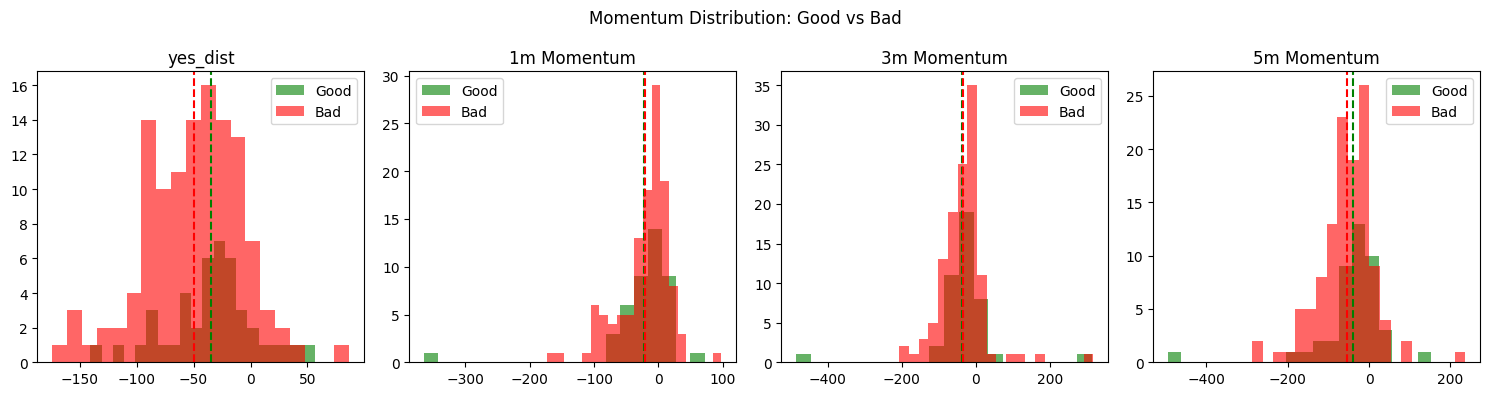

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# good = comb_15[comb_15['reached_70'] == 1]
# bad = comb_15[comb_15['reached_70'] == 0]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# yes_dist
axes[0].hist(good['yes_dist'], bins=20, alpha=0.6, label='Good', color='green')
axes[0].hist(bad['yes_dist'], bins=20, alpha=0.6, label='Bad', color='red')
axes[0].axvline(good['yes_dist'].mean(), color='green', linestyle='--')
axes[0].axvline(bad['yes_dist'].mean(), color='red', linestyle='--')
axes[0].set_title('yes_dist')
axes[0].legend()

# 1m momentum
axes[1].hist(good['1m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[1].hist(bad['1m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[1].axvline(good['1m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[1].axvline(bad['1m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[1].set_title('1m Momentum')
axes[1].legend()

# 3m momentum
axes[2].hist(good['3m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[2].hist(bad['3m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[2].axvline(good['3m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[2].axvline(bad['3m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[2].set_title('3m Momentum')
axes[2].legend()

# 5m momentum
axes[3].hist(good['5m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[3].hist(bad['5m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[3].axvline(good['5m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[3].axvline(bad['5m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[3].set_title('5m Momentum')
axes[3].legend()

plt.suptitle('Momentum Distribution: Good vs Bad')
plt.tight_layout()
plt.show()

In [21]:
# testing

from scipy.stats import norm
import numpy as np

# ===== 1. Extract parameters from your data =====

params = {
    'period': {
        'good': (0.4138,),
        'bad': (0.5862,)
    },
    '1m_yes_dist_momentum': {
        'good': (-17.5070, 51.8947),
        'bad':  (-19.7738, 48.4898)
    },
    '3m_yes_dist_momentum': {
        'good': (-29.0380, 82.5982),
        'bad':  (-32.8337, 73.5574)
    },
    '5m_yes_dist_momentum': {
        'good': (-31.1500, 93.6206),
        'bad':  (-37.5775, 85.6289)
    },
    'yes_dist': {
        'good': (-19.9004, 29.5222),
        'bad':  (-22.8592, 38.3313)
    },
}


# ===== 2. Prediction function =====
def predict(momentum_1m, momentum_3m, momentum_5m, yes_dist):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        '1m_yes_dist_momentum': momentum_1m,
        '3m_yes_dist_momentum': momentum_3m,
        # '5m_yes_dist_momentum': momentum_5m,
        'yes_dist': yes_dist
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob


# ===== 3. Test cases ====

p1 = predict(
    momentum_1m = -26.09,    
    momentum_3m = -88.07,     
    momentum_5m = 0,    
    yes_dist = -39.74      
)
print(f"P(Good): {p1:.1%}")

P(Good): 18.0%


In [30]:
# export model

def write_model_to_json(parameters: dict, filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    params_serializable = {}
    for feature, values in parameters.items():
        params_serializable[feature] = {
            'good': list(values['good']),
            'bad': list(values['bad'])
        }
    
    with open(filepath, 'w') as f:
        json.dump(params_serializable, f, indent=2)
    
    print(f"Model saved to {filepath}")


def load_model_from_json(filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    with open(filepath, 'r') as f:
        params_serializable = json.load(f)
    
    # Convert lists back to tuples
    parameters = {}
    for feature, values in params_serializable.items():
        parameters[feature] = {
            'good': tuple(values['good']),
            'bad': tuple(values['bad'])
        }
    
    return parameters


# Correct dict syntax
params = {
    'period': {
        'good': (0.4138,),
        'bad': (0.5862,)
    },
    '1m_yes_dist_momentum': {
        'good': (-17.5070, 51.8947),
        'bad':  (-19.7738, 48.4898)
    },
    '3m_yes_dist_momentum': {
        'good': (-29.0380, 82.5982),
        'bad':  (-32.8337, 73.5574)
    },
    '5m_yes_dist_momentum': {
        'good': (-31.1500, 93.6206),
        'bad':  (-37.5775, 85.6289)
    },
    'yes_dist': {
        'good': (-19.9004, 29.5222),
        'bad':  (-22.8592, 38.3313)
    },
}



# Write
write_model_to_json(params)

# Read back
loaded = load_model_from_json()
print(loaded['3m_yes_dist_momentum']['good'])  # (-104.941, 95.989)

Model saved to /Users/yingxie/Documents/Git/Quant/Kalshi/btc_15_strategy/models/yes_bayesian.json
(-29.038, 82.5982)


In [130]:
comb_15

,open,high,low,close,tick_count,ticker,floor_strike,yes_ask_low_dollar,yes_bid_high_dollar,no_ask_low_dollar,no_bid_high_dollar,yes_dist,log_return,3m_log_return,5m_log_return,ma3,ma5,ma3_vs_strike,ma5_vs_strike,yes_dist_pct,1m_yes_dist_momentum,3m_yes_dist_momentum,5m_yes_dist_momentum,time_decay,m3_log_return,m5_log_return,m1_yes_dist_momentum,m3_yes_dist_momentum,m5_yes_dist_momentum,hour,minute,subsequent_high,subsequent_low,reached_30,reached_40,reached_50,reached_60,reached_70,reached_90
0,82415.84,82415.84,82414.61,82414.61,0,KXBTC15M-26MAY060815-15,82504.80,0.110,0.160,0.900,0.830,-90.19,0.000000e+00,0.000683,0.000521,82446.116667,82471.182,-0.071127,-0.040747,-0.109315,0.00,-88.76,-103.42,10,0.000683,0.000521,0.00,-88.76,-103.42,7,5,0.540,0.000,1,1,1,0,0,0
1,82338.88,82338.88,82338.88,82338.88,0,KXBTC15M-26MAY060845-45,82384.97,0.120,0.240,0.890,0.750,-46.09,-1.855573e-04,0.000101,0.000227,82349.663333,82358.930,-0.042856,-0.031608,-0.055945,-15.28,-17.07,-92.47,4,0.000101,0.000227,-15.28,-17.07,-92.47,7,41,0.590,0.003,1,1,1,0,0,0
2,82300.54,82353.83,82299.66,82351.47,33,KXBTC15M-26MAY060900-00,82327.84,0.042,0.700,0.959,0.290,23.63,-4.614518e-04,0.000323,0.000261,82383.506667,82387.880,0.067616,0.072928,0.028702,-38.01,-43.68,-35.36,4,0.000323,0.000261,-38.01,-43.68,-35.36,7,56,0.520,0.000,1,1,1,0,0,0
3,82068.42,82068.42,82068.42,82068.42,0,KXBTC15M-26MAY060915-15,82221.92,0.070,0.150,0.940,0.830,-153.50,-1.359404e-03,0.000871,0.000834,82141.553333,82137.466,-0.097744,-0.102715,-0.186690,-111.64,-88.62,-114.01,8,0.000871,0.000834,-111.64,-88.62,-114.01,8,7,0.600,0.001,1,1,1,1,0,0
4,82034.61,82043.74,82032.09,82035.47,24,KXBTC15M-26MAY060930-30,82117.48,0.110,0.250,0.900,0.740,-82.01,5.388058e-05,0.000280,0.000446,82018.960000,82018.630,-0.119974,-0.120376,-0.099869,4.42,43.19,-46.37,5,0.000280,0.000446,4.42,43.19,-46.37,8,25,0.510,0.000,1,1,1,0,0,0
5,81907.76,81907.76,81907.76,81907.76,0,KXBTC15M-26MAY060945-45,81960.23,0.090,0.300,0.917,0.680,-52.47,4.614791e-04,0.000305,0.000783,81866.846667,81853.660,-0.113937,-0.130026,-0.064019,37.79,84.95,-50.40,3,0.000305,0.000783,37.79,84.95,-50.40,8,42,0.600,0.026,1,1,1,1,0,0
6,81741.77,81741.77,81741.77,81741.77,0,KXBTC15M-26MAY061000-00,81895.98,0.077,0.170,0.924,0.820,-154.21,2.248797e-04,0.000395,0.001189,81720.963333,81716.180,-0.213706,-0.219547,-0.188300,18.38,121.54,-67.69,9,0.000395,0.001189,18.38,121.54,-67.69,8,51,0.550,0.000,1,1,1,0,0,0
7,81594.13,81594.13,81594.13,81594.13,0,KXBTC15M-26MAY061015-15,81699.43,0.067,0.200,0.940,0.790,-105.30,1.510027e-04,0.000288,0.000720,81593.703333,81614.650,-0.129409,-0.103771,-0.128887,12.32,9.98,81.34,10,0.000288,0.000720,12.32,9.98,81.34,9,5,0.700,0.000,1,1,1,1,1,0
8,81736.43,81736.43,81736.43,81736.43,0,KXBTC15M-26MAY061100-00,81841.19,0.055,0.190,0.948,0.800,-104.76,-5.791333e-04,0.000355,0.000715,81764.546667,81769.854,-0.093649,-0.087164,-0.128004,-47.35,-49.66,-159.71,7,0.000355,0.000715,-47.35,-49.66,-159.71,9,53,0.570,0.001,1,1,1,0,0,0
9,81501.07,81501.07,81438.96,81458.11,55,KXBTC15M-26MAY061115-15,81531.92,0.035,0.250,0.970,0.740,-73.81,-8.821503e-04,0.000387,0.000375,81516.296667,81538.402,-0.019162,0.007950,-0.090529,-71.89,-112.60,-111.68,2,0.000387,0.000375,-71.89,-112.60,-111.68,10,13,0.830,0.000,1,1,1,1,1,0
